# Aprendizaje inductivo

In [ ]:
#librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# Cargar el archivo CSV usando pandas
df = pd.read_csv('car_evaluation.csv')
# Mostrar las primeras filas del dataset para verificar
print(df.head())

   vhigh vhigh.1  2 2.1  small   low  unacc
0  vhigh   vhigh  2   2  small   med  unacc
1  vhigh   vhigh  2   2  small  high  unacc
2  vhigh   vhigh  2   2    med   low  unacc
3  vhigh   vhigh  2   2    med   med  unacc
4  vhigh   vhigh  2   2    med  high  unacc


In [ ]:
# Ver dimensiones del dataset
print(df.shape)


(1727, 7)


In [ ]:
# Ver resumen del conjunto de datos
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None


In [ ]:
# Renombrar columnas
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

for col in col_names:
    print(df[col].value_counts())


buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [ ]:
df['class'].value_counts()

,count
class,
unacc,1209
acc,384
good,69
vgood,65


In [ ]:
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [ ]:
# Codificar variables categóricas usando OrdinalEncoder
from sklearn.model_selection import train_test_split
import category_encoders as ce

In [ ]:
%pip install category_encoders

In [ ]:
# Declarar el vector de características y la variable objetivo
X = df.drop(['class'], axis=1)
y = df['class']

In [ ]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
# Codificar las variables categóricas
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [ ]:
# Importar y entrenar el modelo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Modelo con 10 árboles
rfc = RandomForestClassifier(n_estimators=10, random_state=0)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=0)

In [ ]:
# Predecir resultados en el conjunto de prueba
y_pred = rfc.predict(X_test)

In [ ]:
# Evaluar el modelo
print('Model accuracy score with 10 decision-trees: {0:0.4f}'.format(accuracy_score(y_test,
y_pred)))
print(classification_report(y_test, y_pred))

Model accuracy score with 10 decision-trees: 0.9474
              precision    recall  f1-score   support

         acc       0.91      0.91      0.91       127
        good       0.59      0.72      0.65        18
       unacc       0.98      0.98      0.98       399
       vgood       0.90      0.73      0.81        26

    accuracy                           0.95       570
   macro avg       0.85      0.84      0.84       570
weighted avg       0.95      0.95      0.95       570



In [ ]:
# Modelo con 100 árboles
rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)
rfc_100.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Predecir resultados
y_pred_100 = rfc_100.predict(X_test)

In [ ]:
# Evaluar el modelo
print('Model accuracy score with 100 decision-trees: {0:0.4f}'.format(accuracy_score(y_test,
y_pred_100)))

Model accuracy score with 100 decision-trees: 0.9649


In [ ]:
# Visualizar las puntuaciones de las características
feature_scores = pd.Series(rfc_100.feature_importances_,
index=X_train.columns).sort_values(ascending=False)
print(feature_scores)

safety      0.291657
persons     0.235380
buying      0.160692
maint       0.134143
lug_boot    0.111595
doors       0.066533
dtype: float64


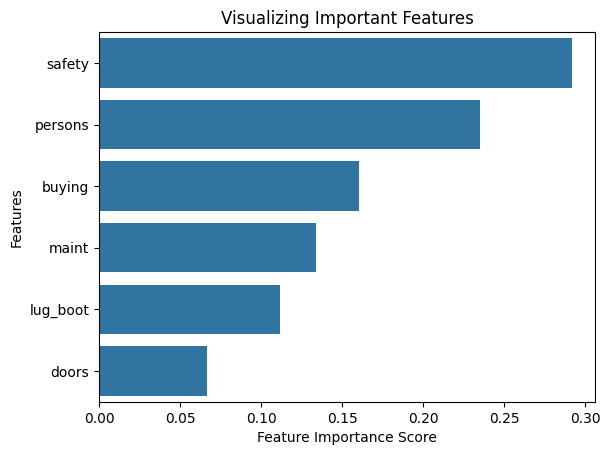

In [ ]:
# Visualizar con seaborn
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.show()

In [ ]:
# Eliminar la característica 'doors' y reconstruir el modelo
X = df.drop(['class', 'doors'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
# Codificar las variables categóricas restantes
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'persons', 'lug_boot', 'safety'])
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [ ]:
# Entrenar el modelo con las características seleccionadas
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Predecir resultados
y_pred = clf.predict(X_test)

In [ ]:
# Evaluar el modelo
print('Model accuracy score with doors variable removed:{0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Model accuracy score with doors variable removed:0.9263


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[108   5  12   2]
 [  1  10   2   5]
 [ 10   0 389   0]
 [  4   1   0  21]]


In [ ]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.88      0.85      0.86       127
        good       0.62      0.56      0.59        18
       unacc       0.97      0.97      0.97       399
       vgood       0.75      0.81      0.78        26

    accuracy                           0.93       570
   macro avg       0.80      0.80      0.80       570
weighted avg       0.93      0.93      0.93       570



Conclusiones
1. La precisión del modelo aumenta con el número de árboles en el modelo Random
Forest. Aumentar de 10 a 100 árboles mejoró la precisión general del modelo.
2. La selección de características importantes mejora la precisión del modelo. Al eliminar
características menos relevantes como 'doors', la precisión del modelo se incrementó.
3. El uso de una matriz de confusión proporciona una visión clara de los tipos de errores
cometidos por el modelo, ayudando a identificar las áreas donde el modelo necesita
ajustes.
4. Este enfoque destaca la importancia de la optimización de hiperparámetros y la
selección de características para mejorar el rendimiento de un modelo de clasificación
en problemas reales.